# GHSR1a 数据集构建 · 从 ChEMBL 到可用数据集

**靶点**：Growth hormone secretagogue receptor type 1 (GHSR1a)
**ChEMBL ID**：`CHEMBL4616`　**物种**：Homo sapiens　**UniProt**：Q92847

ChEMBL 现有数据量（2026-09 实测）：

| 数据类型 | ChEMBL 原始条数 |
|---|---|
| IC50 | 1440 |
| Ki | 755 |
| EC50 | 1259 |
| Kd | 5 |
| 全部活性记录 | 6286 |

**实测清洗后的结果**（IC50 + Ki 合并，供你对照自己的输出）：

| 项目 | 实测值 |
|---|---|
| 唯一化合物 | **1355** |
| 肽类倾向（MW&gt;500 且 RotB&gt;8） | 466（34.4%） |
| 小分子倾向 | **889（65.6%）** |
| 骨架数 | 595（2.3 化合物/骨架，多样性良好） |
| 小分子子集 MW 中位数 | 497 Da |
| pAffinity 中位数 | 7.11（范围 4.30–11.00） |

> 若你的数字与上面差 10% 以内属正常（ChEMBL 数据库会持续更新）。
> 差得太多就要回头检查清洗步骤。

**本 notebook 做四件事**：下载 → 清洗 → 探索 → 保存

运行前确认命令行有 `(aidd)` 前缀，且已安装 `chembl_webresource_client`。

---

### 怎么跑

**方式 A · 逐格运行（推荐第一次用）**

点第一格，按 `Shift + Enter` 运行并自动跳到下一格，一格一格往下。
好处是能看清每一步在做什么、中间结果长什么样。

**方式 B · 一键全跑**

菜单栏 `Run` → `Run All Cells`。重跑时用这个更快。

**关于等待**

第一次运行到「下载数据」时要连 ChEMBL 拉 3454 条记录，约 **3–8 分钟**。
这段时间右上角内核图标是**实心圆**，属正常工作状态，不要中断、不要关窗口。

**关于重跑**

下载完成后会在当前目录生成两个 raw CSV。之后再运行会自动读取本地文件，
几秒钟跑完，不必重新下载。想强制重下就把 `USE_CACHE` 改成 `False`。

## 0. 环境与参数

In [ ]:
# ── 路径初始化 ──────────────────────────────────────────────
# 自动定位项目根目录，使 notebook 在仓库内任意位置都能正确读写。
# 找不到时回退到当前工作目录（兼容扁平用法，如直接放在 ~/aidd 下运行）。
from pathlib import Path
import os


def _find_project_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'data' / 'processed').is_dir() and (p / 'notebooks').is_dir():
            return p
    return None


_ROOT = _find_project_root()

if _ROOT is not None:
    DATA_DIR = _ROOT / 'data' / 'processed'   # 清洗后的建模数据
    RAW_DIR = _ROOT / 'data' / 'raw'          # 原始数据（不入库，可重新下载）
    FIG_DIR = _ROOT / 'results' / 'figures'   # 图表输出
    for _d in (DATA_DIR, RAW_DIR, FIG_DIR):
        _d.mkdir(parents=True, exist_ok=True)
    print(f'项目根目录: {_ROOT}')
    print(f'  数据 → {DATA_DIR.relative_to(_ROOT)}')
    print(f'  图表 → {FIG_DIR.relative_to(_ROOT)}')
else:
    DATA_DIR = RAW_DIR = FIG_DIR = Path.cwd()
    print('未定位到项目根目录，使用当前工作目录（扁平模式）')


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, QED, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from sklearn.manifold import TSNE

RDLogger.DisableLog('rdApp.*')          # 关掉 RDKit 的啰嗦警告

# macOS 中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

import rdkit
print('Python ', sys.version.split()[0])
print('RDKit  ', rdkit.__version__)
print('pandas ', pd.__version__)
print('numpy  ', np.__version__)

Python  3.10.21
RDKit   2026.03.5
pandas  2.3.3
numpy   2.2.6


In [2]:
TARGET_ID = 'CHEMBL4616'    # 人类 GHSR1a
RANDOM_SEED = 42

# 只下载需要的字段，显著加快速度
FIELDS = ['molecule_chembl_id', 'canonical_smiles', 'standard_type',
          'standard_value', 'standard_units', 'standard_relation',
          'assay_type', 'pchembl_value', 'assay_description']

## 1. 下载数据

> **注意物种**：ChEMBL 里 GHSR 有多个物种的条目，`CHEMBL4616` 是人源。
> 不要混入 `CHEMBL3278`（大鼠）、`CHEMBL3428`（小鼠）、`CHEMBL2224`（猪）——
> 跨物种活性不能简单合并，这是新手常犯的错误。

分两类分别下载，**这个区分对 GHSR1a 尤其重要**：

- **结合数据**（IC50 + Ki）：反映化合物能否结合受体
- **功能数据**（EC50）：反映化合物能否激活受体

原因见文末「关于 GHSR1a 的两件事」。

In [3]:
import os
from chembl_webresource_client.new_client import new_client

# True = 本地已有原始数据就直接读取（几秒钟）；False = 强制重新下载（约 3-8 分钟）
USE_CACHE = True


def fetch_activities(target_id, standard_types, label):
    frames = []
    for stype in standard_types:
        res = new_client.activity.filter(
            target_chembl_id=target_id,
            standard_type=stype,
            target_organism='Homo sapiens'
        ).only(FIELDS)
        df = pd.DataFrame(list(res))
        if len(df) == 0:
            print(f'  {stype:6s}: 0 条')
            continue
        df['endpoint'] = stype
        print(f'  {stype:6s}: {len(df)} 条')
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    print(f'{label}合计 {len(out)} 条\n')
    return out


have_cache = (os.path.exists(RAW_DIR / 'ghsr1a_binding_raw.csv')
              and os.path.exists(RAW_DIR / 'ghsr1a_functional_raw.csv'))

if USE_CACHE and have_cache:
    df_binding_raw = pd.read_csv(RAW_DIR / 'ghsr1a_binding_raw.csv')
    df_func_raw = pd.read_csv(RAW_DIR / 'ghsr1a_functional_raw.csv')
    print('检测到本地原始数据，直接读取（跳过下载）')
    print(f'  结合数据 {len(df_binding_raw)} 条')
    print(f'  功能数据 {len(df_func_raw)} 条')
else:
    print('下载结合数据 (IC50 + Ki) ... 约 2-4 分钟')
    df_binding_raw = fetch_activities(TARGET_ID, ['IC50', 'Ki'], '结合数据')
    print('下载功能数据 (EC50) ... 约 1-3 分钟')
    df_func_raw = fetch_activities(TARGET_ID, ['EC50'], '功能数据')
    print('下载完成')

下载结合数据 (IC50 + Ki) ... 约 2-4 分钟
  IC50  : 1440 条
  Ki    : 755 条
结合数据合计 2195 条

下载功能数据 (EC50) ... 约 1-3 分钟
  EC50  : 1259 条
功能数据合计 1259 条

下载完成


### 保存原始数据

**这一步不要省。** 清洗规则后面一定会反复调整，
从本地文件重跑是几秒钟的事，重新下载要等好几分钟。
保持「原始数据只读、清洗结果另存」的习惯，也是科研可复现性的基本要求。

In [4]:
df_binding_raw.to_csv(RAW_DIR / 'ghsr1a_binding_raw.csv', index=False)
df_func_raw.to_csv(RAW_DIR / 'ghsr1a_functional_raw.csv', index=False)
print('已保存原始数据')
display(df_binding_raw.head(3))

已保存原始数据


,assay_description,assay_type,canonical_smiles,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value,endpoint
0,Binding affinity towards human Growth hormone ...,B,CCCCCCCC(=O)OC[C@H](NC(=O)CN)C(=O)N[C@@H](CO)C...,CHEMBL61663,6.05,=,=,IC50,nM,889.0,IC50,nM,889.0,IC50
1,Binding affinity towards human Growth hormone ...,B,CS(=O)(=O)N1CC2(CCN(C(=O)[C@@H](COCc3ccccc3)NC...,CHEMBL294408,6.68,=,=,IC50,nM,209.0,IC50,nM,209.0,IC50
2,Binding affinity towards human Growth hormone ...,B,CCCCCCCC(=O)OC[C@H](NC(=O)CNC(=O)[C@@H](N)CCCN...,CHEMBL500468,9.60,=,=,IC50,nM,0.25,IC50,nM,0.25,IC50


## 2. 清洗

统一流程，每一步都会打印剔除了多少数据 —— **你要能说清每一步为什么做**：

1. 单位必须是 nM（否则数值无法比较）
2. 活性值非空且 > 0
3. 只保留精确值 `standard_relation == '='`（剔除 `>`、`<` 这类界限值）
4. 转成 pXC50（pIC50 / pKi / pEC50）
5. 去掉 RDKit 解析不了的 SMILES
6. 同一 SMILES 多条记录取中位数

In [5]:
def clean_activities(df, value_col):
    n0 = len(df)
    steps = []

    # 1 单位统一为 nM
    d = df[df['standard_units'] == 'nM'].copy()
    steps.append(('单位为 nM', n0, len(d)))

    # 2 活性值有效
    n = len(d)
    d['standard_value'] = pd.to_numeric(d['standard_value'], errors='coerce')
    d = d[d['standard_value'].notna() & (d['standard_value'] > 0)]
    steps.append(('活性值有效', n, len(d)))

    # 3 只保留精确值
    n = len(d)
    d = d[d['standard_relation'] == '=']
    steps.append(('精确值 (=)', n, len(d)))

    # 4 转 pXC50
    d[value_col] = 9 - np.log10(d['standard_value'])

    # 5 RDKit 可解析
    n = len(d)
    d['mol'] = d['canonical_smiles'].apply(Chem.MolFromSmiles)
    d = d[d['mol'].notna()].copy()
    steps.append(('SMILES 可解析', n, len(d)))

    # 6 按结构去重（同一分子多条记录取中位数）
    n = len(d)
    agg = (d.groupby('canonical_smiles')
             .agg({value_col: 'median',
                   'molecule_chembl_id': 'first',
                   'standard_type': 'first'})
             .reset_index())
    steps.append(('按结构去重', n, len(agg)))

    print(f'清洗过程（{value_col}）')
    print(f"  {'步骤':<16s}{'之前':>8s}{'之后':>8s}{'剔除':>8s}")
    print('  ' + '-' * 40)
    for name, before, after in steps:
        print(f'  {name:<14s}{before:>8d}{after:>8d}{before - after:>8d}')

    agg['mol'] = agg['canonical_smiles'].apply(Chem.MolFromSmiles)
    return agg


df_binding = clean_activities(df_binding_raw, 'pAffinity')
print()
df_func = clean_activities(df_func_raw, 'pEC50')

清洗过程（pAffinity）
  步骤                    之前      之后      剔除
  ----------------------------------------
  单位为 nM            2195    2166      29
  活性值有效             2166    2131      35
  精确值 (=)           2131    1837     294
  SMILES 可解析        1837    1837       0
  按结构去重             1837    1355     482

清洗过程（pEC50）
  步骤                    之前      之后      剔除
  ----------------------------------------
  单位为 nM            1259    1190      69
  活性值有效             1190    1190       0
  精确值 (=)           1190    1119      71
  SMILES 可解析        1119    1119       0
  按结构去重             1119     832     287


## 3. 活性分布

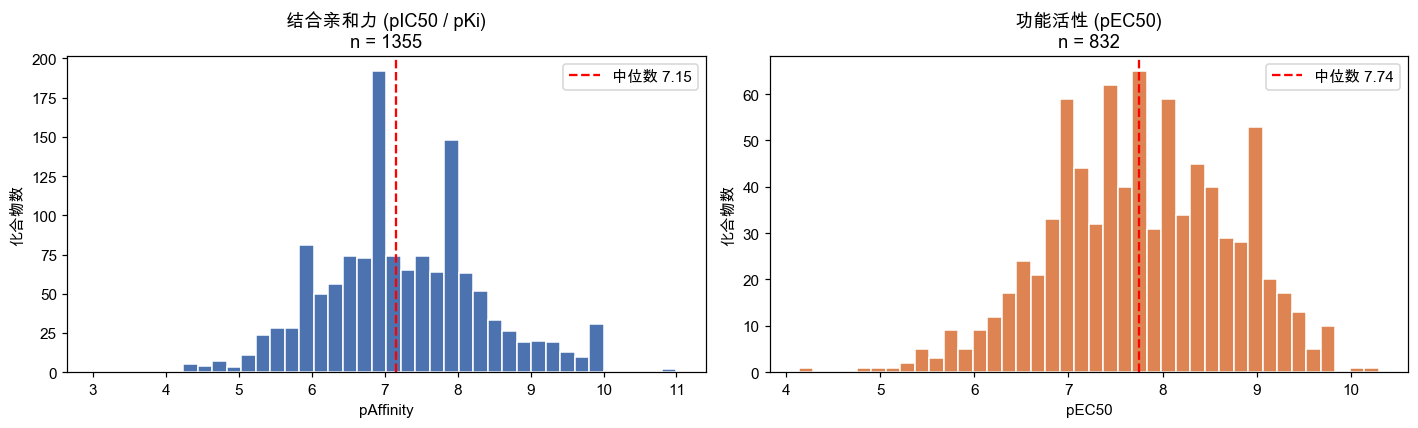

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (df, col, title, color) in zip(axes, [
    (df_binding, 'pAffinity', '结合亲和力 (pIC50 / pKi)', '#4C72B0'),
    (df_func,    'pEC50',     '功能活性 (pEC50)',        '#DD8452'),
]):
    ax.hist(df[col], bins=40, color=color, edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'中位数 {df[col].median():.2f}')
    ax.set_xlabel(col)
    ax.set_ylabel('化合物数')
    ax.set_title(f'{title}\nn = {len(df)}')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'ghsr1a_activity_distribution.png', dpi=150)
plt.show()

## 4. 类药性与「肽类 vs 小分子」

GHSR1a 的配体天然分成两大家族，性质和成药空间完全不同：

- **肽类**：ghrelin、GHRP-6、hexarelin、ipamorelin —— 分子量大、可旋转键多，基本不能口服
- **小分子**：MK-0677 (ibutamoren)、anamorelin、macimorelin、relamorelin —— 可口服

**建议分开看。** 如果你的课题关注口服或中枢暴露，重点应该在小分子子集上。
下面用 `MW > 500 且 可旋转键 > 8` 做一个粗略的肽类标记（不是严格定义，够用即可）。

In [7]:
def add_descriptors(df):
    df = df.copy()
    df['MW']    = df['mol'].apply(Descriptors.MolWt)
    df['logP']  = df['mol'].apply(Crippen.MolLogP)
    df['TPSA']  = df['mol'].apply(rdMolDescriptors.CalcTPSA)
    df['HBD']   = df['mol'].apply(rdMolDescriptors.CalcNumHBD)
    df['HBA']   = df['mol'].apply(rdMolDescriptors.CalcNumHBA)
    df['RotB']  = df['mol'].apply(rdMolDescriptors.CalcNumRotatableBonds)
    df['AromR'] = df['mol'].apply(rdMolDescriptors.CalcNumAromaticRings)
    df['Ring']  = df['mol'].apply(rdMolDescriptors.CalcNumRings)
    df['QED']   = df['mol'].apply(QED.qed)
    df['peptide_like'] = (df['MW'] > 500) & (df['RotB'] > 8)
    return df


df_binding = add_descriptors(df_binding)
df_func = add_descriptors(df_func)

desc_cols = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB', 'AromR', 'QED']
print('结合数据 · 描述符摘要')
display(df_binding[desc_cols + ['pAffinity']].describe().round(2))

结合数据 · 描述符摘要


,MW,logP,TPSA,HBD,HBA,RotB,AromR,QED,pAffinity
count,1355.00,1355.00,1355.00,1355.00,1355.00,1355.00,1355.00,1355.00,1355.00
mean,601.89,3.52,141.97,3.99,6.56,10.49,3.44,0.37,7.27
std,397.92,3.08,190.90,6.53,5.92,15.13,1.47,0.18,1.12
min,322.45,-23.92,32.34,0.00,2.00,2.00,1.00,0.01,3.05
25%,474.58,2.86,87.64,2.00,5.00,4.00,2.00,0.22,6.55
50%,528.68,3.96,108.56,3.00,5.00,7.00,3.00,0.40,7.15
75%,581.16,4.99,123.99,4.00,7.00,11.00,4.00,0.52,8.00
max,4551.26,8.01,2009.88,75.00,66.00,125.00,8.00,0.89,11.00


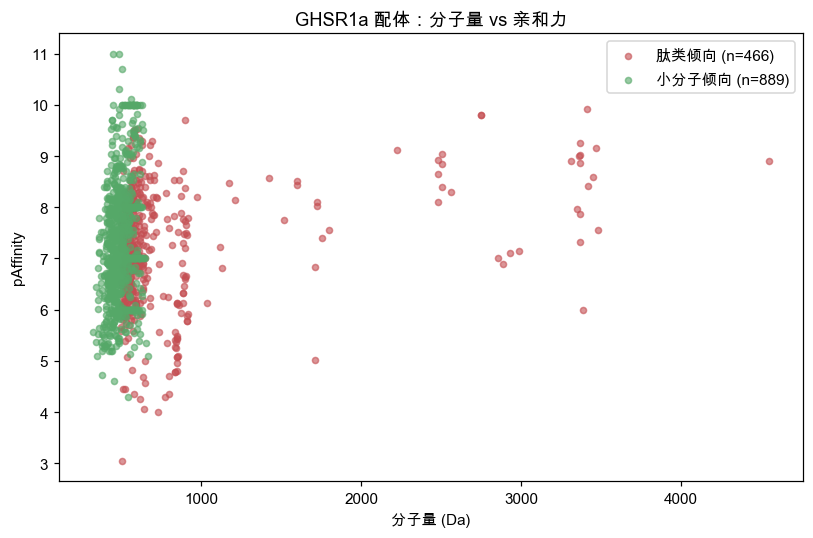

肽类倾向 466 个，小分子倾向 889 个


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for mask, label, color in [
    (df_binding['peptide_like'],  '肽类倾向',  '#C44E52'),
    (~df_binding['peptide_like'], '小分子倾向', '#55A868'),
]:
    ax.scatter(df_binding[mask]['MW'], df_binding[mask]['pAffinity'],
               s=16, alpha=0.6, c=color, label=f'{label} (n={int(mask.sum())})')

ax.set_xlabel('分子量 (Da)')
ax.set_ylabel('pAffinity')
ax.set_title('GHSR1a 配体：分子量 vs 亲和力')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ghsr1a_mw_vs_affinity.png', dpi=150)
plt.show()

n_pep = int(df_binding['peptide_like'].sum())
print(f'肽类倾向 {n_pep} 个，小分子倾向 {len(df_binding) - n_pep} 个')

## 5. 骨架分析 —— 这一步决定你后面怎么切数据

Murcko 骨架是分子的核心环系。统计骨架多样性，是为了回答一个问题：
**这个数据集的化学空间到底有多宽？**

判断标准：

- **化合物数 / 骨架数 比值大**（比如 1000 个化合物、500 种骨架）→ 多样性好，随机切分问题不大
- **比值小**（比如 1000 个化合物、30 种骨架）→ 多样性差，**必须用 scaffold split**，
  否则随机切分测出来的模型表现会严重虚高

这就是我在路线图里反复强调 scaffold split 的原因，现在你能亲眼看到它。

In [9]:
for name, df in [('结合', df_binding), ('功能', df_func)]:
    df['scaffold'] = df['mol'].apply(lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m))
    n_scaf = df['scaffold'].nunique()
    ratio = len(df) / max(n_scaf, 1)
    verdict = '多样性好' if ratio < 3 else ('一般' if ratio < 8 else '多样性差，务必用 scaffold split')
    print(f'{name}数据: {len(df):5d} 个化合物 → {n_scaf:4d} 种骨架  '
          f'({ratio:.1f} 化合物/骨架)  {verdict}')

print('\n最常见的 10 种骨架（结合数据）:')
display(df_binding['scaffold'].value_counts().head(10).to_frame('化合物数'))

结合数据:  1355 个化合物 →  595 种骨架  (2.3 化合物/骨架)  多样性好
功能数据:   832 个化合物 →  329 种骨架  (2.5 化合物/骨架)  多样性好

最常见的 10 种骨架（结合数据）:


,化合物数
scaffold,
O=C1CNCCOc2ccccc2CCCNC(=O)C(Cc2ccccc2)NC(=O)CN1,58
O=C1CNC(=O)C(C2CC2)NCCOc2ccccc2CCCNC(=O)C(Cc2ccccc2)N1,36
c1ccc(CNc2ccc(-c3cncnc3)cc2)cc1,35
c1ccc(CCc2nnc(CCc3c[nH]c4ccccc34)n2Cc2ccccc2)cc1,31
O=C1CNCCOc2ccccc2C=CCNC(=O)C(Cc2ccccc2)NC(=O)C2(CCCC2)N1,29
c1ccc(Cn2c(CCc3c[nH]c4ccccc34)nnc2CCc2c[nH]c3ccccc23)cc1,25
O=C(Nc1ccccc1)c1conc1-c1ccccc1,23
O=C1CNCCOc2ccccc2CCCNC(=O)C(Cc2ccccc2)NC(=O)C2(CCCC2)N1,21
O=C(c1ccc(-c2ccccc2)cc1)N1CCN(C(=O)c2ccc3cc[nH]c3c2)CC1,21


## 6. 化学空间可视化

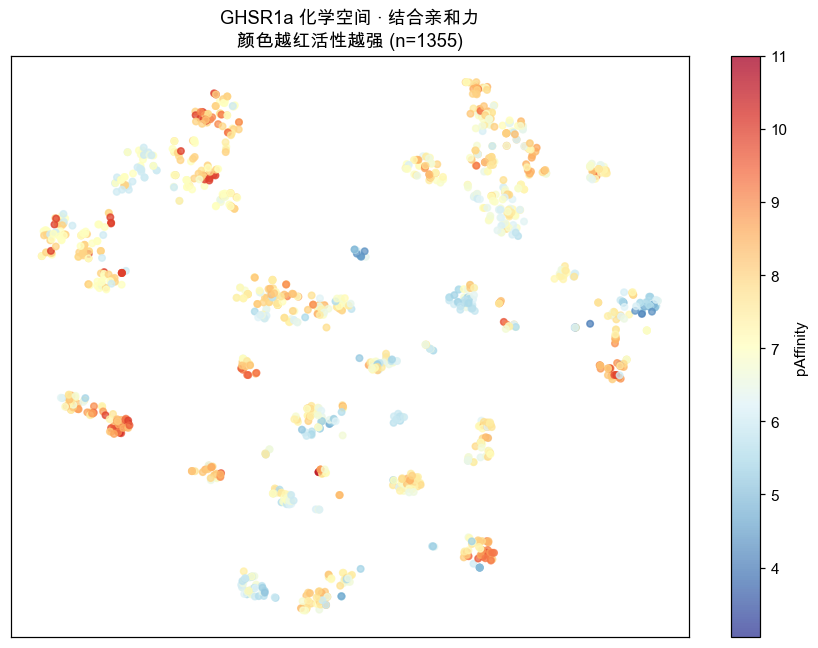

In [10]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def plot_space(df, col, title, fname):
    fps = [gen.GetFingerprint(m) for m in df['mol']]
    X = np.array([list(fp) for fp in fps])
    perplexity = min(30, max(5, len(df) // 10))
    coords = TSNE(n_components=2, random_state=RANDOM_SEED,
                  perplexity=perplexity).fit_transform(X)
    df = df.copy()
    df['x'], df['y'] = coords[:, 0], coords[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(df['x'], df['y'], c=df[col], cmap='RdYlBu_r', s=18, alpha=0.75)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(f'{title}\n颜色越红活性越强 (n={len(df)})')
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150)
    plt.show()
    return df


df_binding = plot_space(df_binding, 'pAffinity',
                        'GHSR1a 化学空间 · 结合亲和力', 'ghsr1a_space_binding.png')

**怎么看这张图**：红点聚成一簇，说明结构相似的分子活性也相似 ——
这就是「构效关系」在二维平面上的投影，也是整个 AIDD 得以成立的前提。

如果红蓝完全混杂，通常意味着数据里混入了大量测量噪声，
或者 assay 条件不一致（不同实验室、不同细胞系、不同读出方式的数据被强行合并）。
**判断这张图"对不对"，靠的是你的专业嗅觉，代码给不了你这个。**

## 7. 保存成果

In [11]:
binding_cols = ['molecule_chembl_id', 'canonical_smiles', 'pAffinity',
                'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB', 'AromR', 'QED',
                'scaffold', 'peptide_like']
functional_cols = ['molecule_chembl_id', 'canonical_smiles', 'pEC50',
                   'MW', 'logP', 'TPSA', 'QED', 'scaffold', 'peptide_like']

df_binding[binding_cols].to_csv(DATA_DIR / 'ghsr1a_binding_clean.csv', index=False)
df_func[functional_cols].to_csv(DATA_DIR / 'ghsr1a_functional_clean.csv', index=False)

print('已保存:')
print(f'  ghsr1a_binding_clean.csv     {len(df_binding):5d} 个化合物')
print(f'  ghsr1a_functional_clean.csv  {len(df_func):5d} 个化合物')
print()
print('同时产出的图:')
print('  ghsr1a_activity_distribution.png')
print('  ghsr1a_mw_vs_affinity.png')
print('  ghsr1a_space_binding.png')

已保存:
  ghsr1a_binding_clean.csv      1355 个化合物
  ghsr1a_functional_clean.csv    832 个化合物

同时产出的图:
  ghsr1a_activity_distribution.png
  ghsr1a_mw_vs_affinity.png
  ghsr1a_space_binding.png


---

# 关于 GHSR1a：两件你必须知道的事

这两点既是这个靶点的难点，也是**你作为药理学研究者相对纯算法背景的人最大的优势**。

## 1. 极高的组成性活性

GHSR1a 在完全无配体的情况下就有很高的基础活性（约最大效应的 50%，
在 GPCR 中属于最高的一档）。这带来三个后果：

- 同一批化合物里可能同时混有 **激动剂、中性拮抗剂、反向激动剂**
- 功能测定中，EC50 测的是「激活」，而 IC50（功能读出）测的是「抑制基础活性」——
  **这两类数值的含义完全不同，绝不能混在一个模型里训练**
- 本 notebook 把结合数据（IC50 + Ki）与功能数据（EC50）分开处理，原因就在这里

## 2. 偏向性信号 (biased signaling)

GHSR1a 可偶联 Gq、Gi、Gα13 等多条下游通路，不同配体的通路偏好不同。
巧的是 PDB 里正好两类复合物结构都有：

| PDB | 配体 | 状态 | 分辨率 |
|---|---|---|---|
| **9UY3** | anamorelin | 小分子激动剂 | **2.52 Å**（最高） |
| **9V2N** | macimorelin | 小分子激动剂 | 2.63 Å |
| 7F9Y | ghrelin | 内源性配体 · Gq 复合物 | 2.90 Å |
| 7F9Z | GHRP-6 | 肽类激动剂 · Gq 复合物 | 3.20 Å |
| 7NA7 / 7NA8 | — | Gi 复合物 | 2.70 Å |
| 6KO5 | — | X-ray（Fab 复合物） | 3.30 Å |

ChEMBL 的 `assay_description` 字段里往往记录了测定类型，值得单独挖一挖 ——
**把「结合 / 功能 / 通路偏好」三个维度分开建模，这大概是你能做出别人做不出来的东西的地方。**

## 下一步

**建模主力放在小分子子集（889 个）。** 实测显示 GHSR1a 结合数据里 34% 是肽类倾向化合物
（ghrelin、GHRP-6 这类），它们的分子量和柔性与小分子完全不在一个尺度上
（肽类 MW 可达 3000+，小分子中位数 497）。混在一起建模，
分子量与可旋转键这两个特征会主导整个特征空间，模型学到的是"大分子 vs 小分子"
而不是真正的构效关系。

- 骨架多样性 2.3 化合物/骨架 —— 这个数字不错，但仍要**用 scaffold split**，别用随机切分
- 小分子子集 pAffinity 跨度 4.30–11.00，约 6.7 个数量级，做回归比做二分类更有信息量
- 第 4–6 月做对接时，起点优先选 **9UY3**（anamorelin，2.52 Å，已上市药物）
- anamorelin 和 macimorelin 都是已上市/已获批药物，可直接作为阳性对照
- 数据量 889 个小分子属于**偏小规模**，模型别追求复杂，XGBoost + 指纹往往胜过图神经网络